In [ ]:
library(Signac)
library(Seurat)
library(ggplot2)
library(Matrix)
library(GenomicRanges)
library(zellkonverter)
library(reticulate)
library(SingleCellExperiment)
library(stringr)
library(svglite)
library(glue)
library(EnsDb.Hsapiens.v86)
library(BSgenome.Hsapiens.UCSC.hg38)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following object is masked from ‘package:SeuratObject’:

    intersect


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min


Loading required package: S4Vectors


Attaching package: ‘S4Vectors’


The following obj

## load data

In [ ]:
path <- '/path/data'
marker <- 'RPL36'
marker_celltype <- c('NK', 'B', 'T')
chrom <- 'chr19'
region <- 'chr19-5574947-5791876'
distance <- 1e+05
marker_type <- 'T'
fold <- 'independence'
atac_file <- 'atac_chr19_independence.h5ad'
rna_file <- 'rna_independence.h5ad'
ct_file <- 'celltype.csv'

In [ ]:
cell_types <- read.csv(glue("{path}/statistic/{ct_file}"))[, 'ct_a']
indices <- cell_types %in% marker_celltype
print(head(cell_types))
adata <- readH5AD(
    glue("{path}/atac_data/{atac_file}"),
    use_hdf5 = TRUE,
    reader = "R",
    skip_assays = FALSE,
    assay_list = list(counts = "X"))
print(dim(adata))  # rows = feature (gene/peak), columns = cells
assayNames(adata)
counts <- assay(adata, "X")
counts <- as(counts, "dgCMatrix")
# counts <- t(counts)
print(nrow(rowData(adata)))
print(nrow(colData(adata)))
rownames(counts) <- rownames(rowData(adata))  # peaks
colnames(counts) <- rownames(colData(adata))  # cells

[1] "NK" "T"  "NK" "NK" "NK" "NK"
[1] 25803 38770


[1] "X"

[1] 25803
[1] 38770


In [5]:
chrom_assay <- CreateChromatinAssay(
    counts = counts,
    sep = c("-", "-"),
    genome = "hg38"
)
seurat_obj <- CreateSeuratObject(
counts = chrom_assay, 
assay = "peaks",
meta.data = cbind(as.data.frame(colData(adata)), 
                     cell_type = cell_types)
)
frags <- CreateFragmentObject(
  path = glue("{path}/perturbation/{chrom}_{fold}_sorted.fragments.tsv.gz"),
  cells = colnames(seurat_obj)
)
Fragments(seurat_obj[["peaks"]]) <- frags
seurat_obj <- seurat_obj[, indices]
head(rownames(seurat_obj))  # peaks/chromatin regions
head(colnames(seurat_obj))  # cell barcodes
class(seurat_obj[["peaks"]])

annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevelsStyle(annotations) <- "UCSC"
annotations_chr <- keepSeqlevels(annotations, chrom, pruning.mode = "coarse")
Annotation(seurat_obj[["peaks"]]) <- annotations_chr

Warning message in CreateChromatinAssay(counts = counts, sep = c("-", "-"), genome = "hg38"):
"Overlapping ranges supplied. Ranges should be non-overlapping."
Computing hash



[1] "chr19-97171-98134"   "chr19-98335-98802"   "chr19-98802-99161"  
[4] "chr19-99619-100182"  "chr19-103093-103447" "chr19-104508-105088"

[1] "AAACCAACAATCCCTT-1_1" "AAACCGAAGGTCCACA-1_1" "AAACCGCGTACGCGCA-1_1"
[4] "AAACCGCGTCTAACCT-1_1" "AAACGCGCACCCTCAC-1_1" "AAAGCACCACCTAAGC-1_1"

[1] "ChromatinAssay"
attr(,"package")
[1] "Signac"

Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

In [ ]:
rna_obj <- readH5AD(
    glue("{path}/rna_data/{rna_file}"),
    use_hdf5 = TRUE,
    reader = "R",
    skip_assays = FALSE,
    assay_list = list(counts = "X"))
rna_obj <- rna_obj[, indices]
print(dim(rna_obj))
gene_names <- readLines(glue("{path}/rna_data/rna_cellplm_gene_names.txt"))
gene_names <- trimws(gene_names)
assayNames(rna_obj)
counts <- assay(rna_obj, "X")
counts <- as(counts, "dgCMatrix")
rownames(counts) <- gene_names  # genes
colnames(counts) <- rownames(colData(rna_obj))  # cells
rna_assay <- CreateAssayObject(
  counts = counts,
  meta.data = as.data.frame(colData(rna_obj), 
                     cell_type = cell_types)
)
seurat_obj[["RNA"]] <- rna_assay
seurat_obj <- NormalizeData(seurat_obj, assay = "RNA")
print("RNA data normalized")
annotations <- GetGRangesFromEnsDb(ensdb = EnsDb.Hsapiens.v86)
seqlevelsStyle(annotations) <- "UCSC"
marker_anno <- annotations[annotations$gene_name == marker]  # only show target gene in panel
strand(marker_anno) <- "+"
Annotation(seurat_obj) <- marker_anno

gene.coords <- genes(EnsDb.Hsapiens.v86)
seqlevelsStyle(gene.coords) <- "UCSC"
marker_coords <- gene.coords[gene.coords$gene_name == marker]
strand(marker_coords) <- "+"
tss <- as.data.frame(marker_coords)$start[[1]]
print(tss)
print(marker_coords)
print(marker %in% rownames(seurat_obj[["RNA"]]))


[1] 15021 36618


[1] "X"

[1] "RNA data normalized"


Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warning message in .merge_two_Seqinfo_objects(x, y):
"The 2 combined objects have no sequence levels in common. (Use
  suppressWarnings() to suppress this warning.)"
Warn

[1] 5674947
GRanges object with 1 range and 6 metadata columns:
                  seqnames          ranges strand |         gene_id   gene_name
                     <Rle>       <IRanges>  <Rle> |     <character> <character>
  ENSG00000130255    chr19 5674947-5691876      + | ENSG00000130255       RPL36
                    gene_biotype seq_coord_system      symbol entrezid
                     <character>      <character> <character>   <list>
  ENSG00000130255 protein_coding       chromosome       RPL36    25873
  -------
  seqinfo: 357 sequences (1 circular) from 2 genomes (hg38, GRCh38)
[1] TRUE


## filter out the truth labels

In [ ]:
# # library(BSgenome.Hsapiens.UCSC.hg38)
seurat_obj_peaks <- RegionStats(
  object = seurat_obj,
  assay = "peaks",
  genome = BSgenome.Hsapiens.UCSC.hg38  # Use appropriate genome for your data
)
links_df <- read.csv(glue("{path}/perturbation/gene_peak_nearby/{marker}_nearby_labels.csv"), stringsAsFactors = FALSE, row.names = 1)
links_df <- as.data.frame(links_df)

links_all <- data.frame(
peak = rownames(links_df),
label = links_df[[marker_type]],
gene = marker,
stringsAsFactors = FALSE
)
links_all <- links_all[!is.na(links_all$label) & links_all$label != 0, ]

peak_ranges <- StringToGRanges(links_all$peak)
gene_end <- as.data.frame(marker_coords)$end[[1]]
peaks_in_range <- which(
  as.character(seqnames(peak_ranges)) == chrom &
  (start(peak_ranges) >=  tss - distance) & (end(peak_ranges) <= gene_end + distance)
)
peak_name_list <- character()
for (i in peaks_in_range) {
  peak_start <- start(peak_ranges)[i]
  start_pos <- min(peak_start, tss)
  end_pos <- max(peak_start, tss)
  new_peak_name <- paste0(chrom, "-", start_pos, "-", end_pos)
  peak_name_list <- c(peak_name_list, new_peak_name)
}
links_all <- links_all[peaks_in_range, ]

links_gr <- StringToGRanges(peak_name_list)
mcols(links_gr)$score <- links_all$label
mcols(links_gr)$gene <- links_all$gene

seurat_obj_peaks@assays[["peaks"]]@links <- links_gr
top_k <- 0
if (!is.null(Links(seurat_obj_peaks))) {
  print("Links data present, total detected: ")
  top_k <- length(Links(seurat_obj_peaks))
  print(top_k)
  strand(Links(seurat_obj_peaks)) <- "+"
  print(Links(seurat_obj_peaks))
} else {
  print("Links data absent")
}
score_truth <- Links(seurat_obj_peaks)$score

[1] "Links data present, total detected: "
[1] 6
GRanges object with 6 ranges and 2 metadata columns:
      seqnames          ranges strand |     score        gene
         <Rle>       <IRanges>  <Rle> | <integer> <character>
  [1]    chr19 5621167-5674947      + |         1       RPL36
  [2]    chr19 5674947-5679449      + |         1       RPL36
  [3]    chr19 5674947-5686335      + |         1       RPL36
  [4]    chr19 5674947-5690008      + |         1       RPL36
  [5]    chr19 5674947-5719332      + |         1       RPL36
  [6]    chr19 5674947-5790445      + |         1       RPL36
  -------
  seqinfo: 1 sequence from an unspecified genome; no seqlengths


### plot the truth labels as links

Warning message:
"`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."
Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."


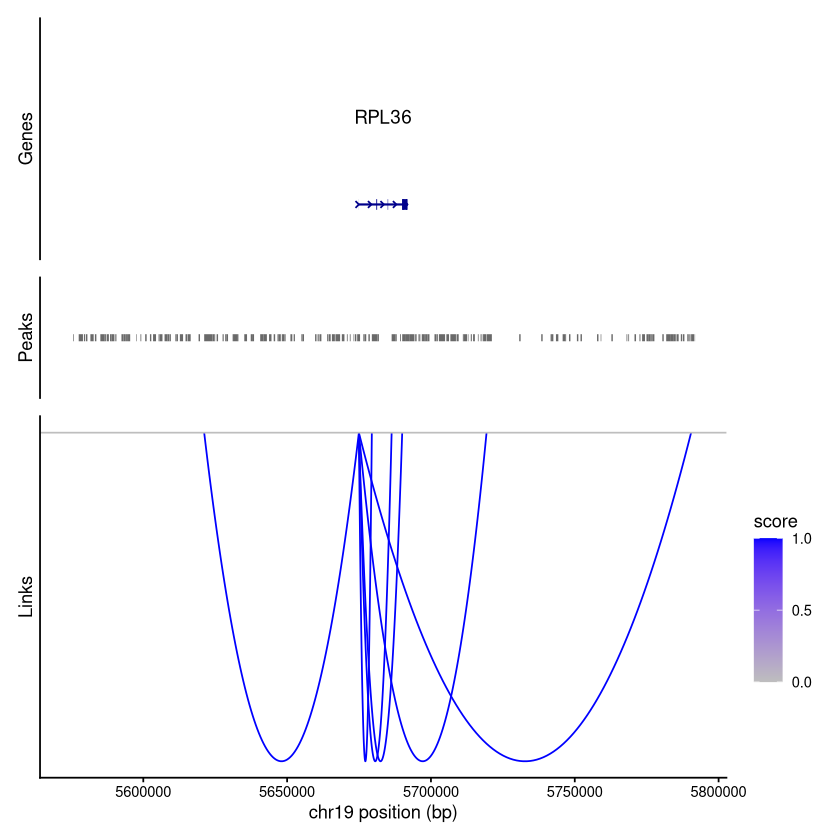

In [ ]:
gene_plot <- AnnotationPlot(
  object = seurat_obj_peaks,
  region = region
)
text_layers <- which(sapply(gene_plot$layers, function(l)
  inherits(l$geom, "GeomText")
))
gene_plot$layers[[text_layers[1]]]$aes_params$size <- 4
peak_plot <- PeakPlot(
  object = seurat_obj_peaks,
  region = region
)
link_plot <- LinkPlot(
  object = seurat_obj_peaks,
  region = region
)
cov_plot <- CombineTracks(
  plotlist = list(gene_plot, peak_plot, link_plot),
  heights = c(2, 1, 3),
)
cov_plot

##  filter out the predicted links based on perturbation score

In [ ]:
use_python("/home/user/anaconda3/envs/pyt/bin/python", required = TRUE)

create_links_gr_simple <- function(h5ad_path, marker, tss, gene_end, chrom, top_k, ct='T', distance = 5e+05) {
  sc <- reticulate::import("scanpy")
  adata <- sc$read_h5ad(h5ad_path)
  
  delta_matrix <- as.matrix(adata$X)
  
  obs_df <- as.data.frame(adata$obs)
  var_df <- as.data.frame(adata$var)
  
  rownames(delta_matrix) <- rownames(adata$obs)
  colnames(delta_matrix) <- rownames(adata$var)
  
  t_cell_indices <- which(obs_df$ct_a == ct)
  
  if (length(t_cell_indices) == 1) {
    t_cell_delta <- delta_matrix[t_cell_indices, ]
  } else {
    t_cell_delta <- colMeans(abs(delta_matrix[t_cell_indices, ]), na.rm = TRUE)
  }
  
  links_all <- data.frame(
    peak = colnames(delta_matrix),
    label = t_cell_delta,
    gene = marker,
    stringsAsFactors = FALSE
  )
  
  links_all <- links_all[!is.na(links_all$label), ]
  
  peak_ranges <- StringToGRanges(links_all$peak)
  
  peaks_in_range <- which(
    as.character(seqnames(peak_ranges)) == chrom &
    (start(peak_ranges) >= tss - distance) & 
    (end(peak_ranges) <= gene_end + distance)
  )

  peak_name_list <- character()
  for (i in peaks_in_range) {
    peak_start <- start(peak_ranges)[i]
    start_pos <- min(peak_start, tss)
    end_pos <- max(peak_start, tss)
    new_peak_name <- paste0(chrom, "-", start_pos, "-", end_pos)
    peak_name_list <- c(peak_name_list, new_peak_name)
  }
  
  # update links_all
  links_all <- links_all[peaks_in_range, ]
  if (nrow(links_all) > top_k) {
    top_indices <- order(abs(links_all$label), decreasing = TRUE)[1:top_k]
    links_all <- links_all[top_indices, ]
    peak_name_list <- peak_name_list[top_indices]
  }
  
  # create links_gr
  links_gr <- StringToGRanges(peak_name_list)
  mcols(links_gr)$score <- links_all$label
  mcols(links_gr)$gene <- links_all$gene
  
  return(links_gr)
}

In [ ]:
links_gr <- create_links_gr_simple(glue("{path}/perturbation/gene_peak_regulation/atac_delta_{fold}_{marker_type}_{marker}_{chrom}.h5ad"), marker, tss, gene_end, chrom, top_k, ct = marker_type, distance = distance)
seurat_obj_peaks@assays[["peaks"]]@links <- links_gr
if (!is.null(Links(seurat_obj_peaks))) {
  print("Links data present, total detected: ")
  print(length(Links(seurat_obj_peaks)))
  strand(Links(seurat_obj_peaks)) <- "+"
  print(Links(seurat_obj_peaks))
} else {
  print("Links data absent")
}
score_truth <- Links(seurat_obj_peaks)$score

[1] "Links data present, total detected: "
[1] 6
GRanges object with 6 ranges and 2 metadata columns:
      seqnames          ranges strand |     score        gene
         <Rle>       <IRanges>  <Rle> | <numeric> <character>
  [1]    chr19 5674947-5719332      + | 0.0624720       RPL36
  [2]    chr19 5674947-5790445      + | 0.0586957       RPL36
  [3]    chr19 5674947-5686335      + | 0.0580070       RPL36
  [4]    chr19 5621167-5674947      + | 0.0527019       RPL36
  [5]    chr19 5674947-5679449      + | 0.0509853       RPL36
  [6]    chr19 5674947-5690008      + | 0.0359515       RPL36
  -------
  seqinfo: 1 sequence from an unspecified genome; no seqlengths


## plot the final links

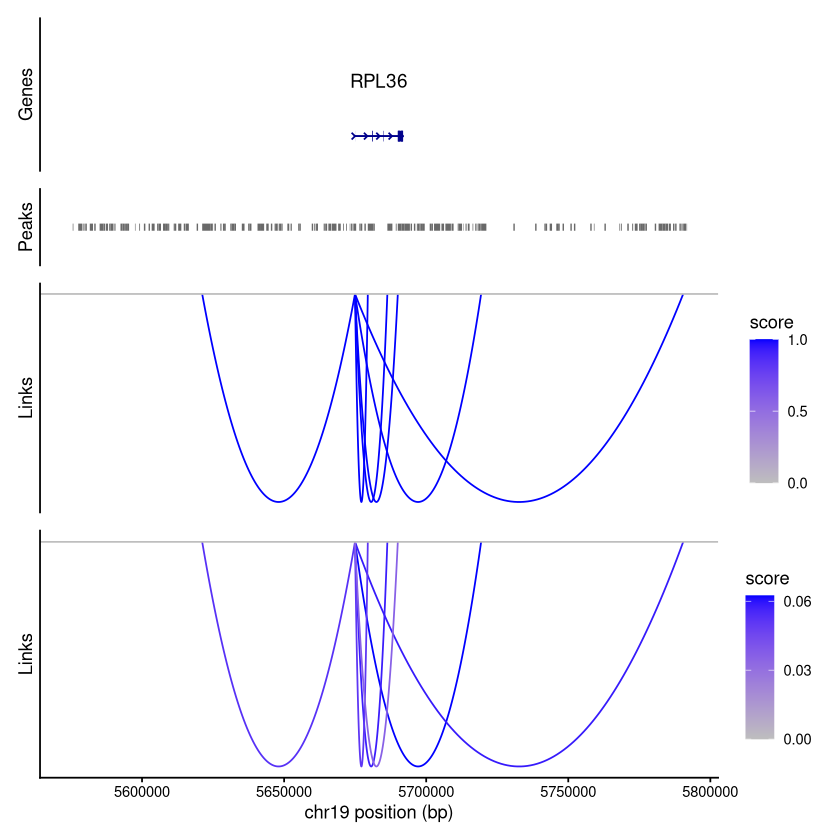

In [ ]:
link_plot <- LinkPlot(seurat_obj_peaks@assays[["peaks"]], region = region)
whole_plot <- CombineTracks(
  plotlist = list(cov_plot, link_plot),
  heights = c(6, 3),
)
whole_plot

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


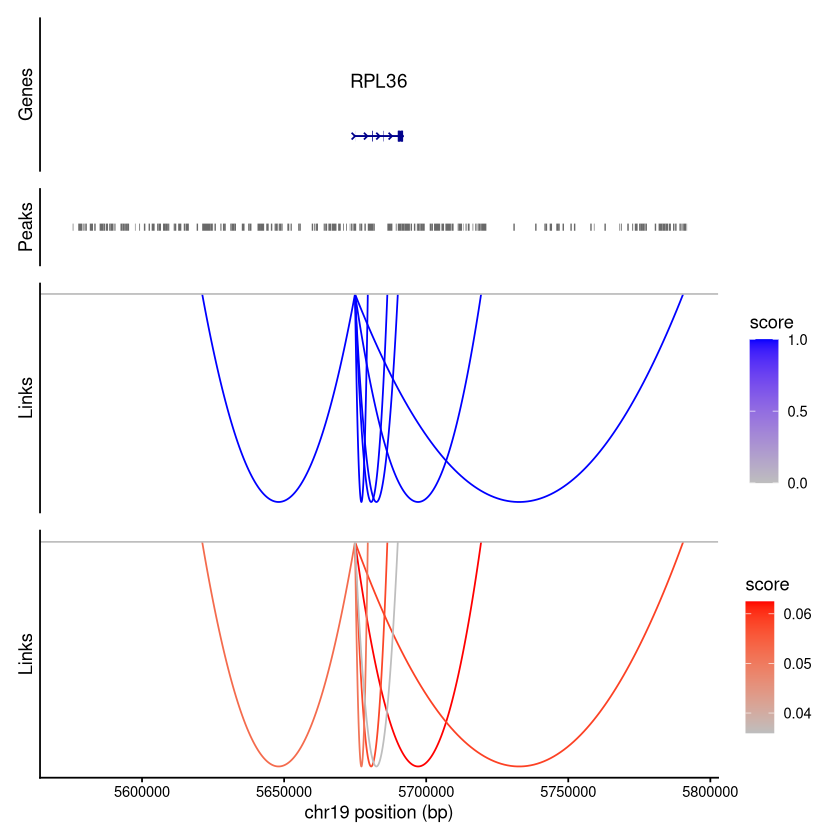

In [ ]:
all_plot <- whole_plot + 
  scale_color_gradient(low = "gray", high = "red", 
    breaks = scales::pretty_breaks(n = 3),
    guide = guide_colorbar(
    barwidth = 1.2,
    barheight = 5.5,
  ))
all_plot

## save the plot

In [14]:
ggsave(
  filename = glue("{path}/perturbation/gene_peak_arc/{chrom}_{fold}_{marker_type}_{marker}_link_plot.pdf"),
  plot = all_plot,
  width = 10,
  height = 6,
  dpi = 300
)